<h2>Downloading the Data</h2>

In [ ]:
!wget -O FuelConsumption.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
%matplotlib inline

In [23]:
df = pd.read_csv("FuelConsumption.csv")
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [24]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_CITY','FUELCONSUMPTION_HWY','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.head()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,9.9,6.7,8.5,196
1,2.4,4,11.2,7.7,9.6,221
2,1.5,4,6.0,5.8,5.9,136
3,3.5,6,12.7,9.1,11.1,255
4,3.5,6,12.1,8.7,10.6,244


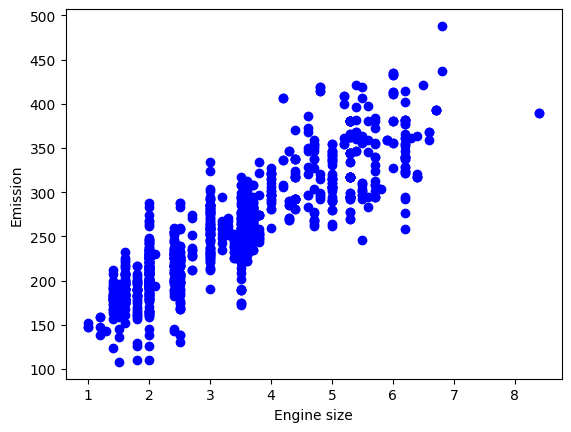

In [25]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

In [26]:
msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test = cdf[~msk]

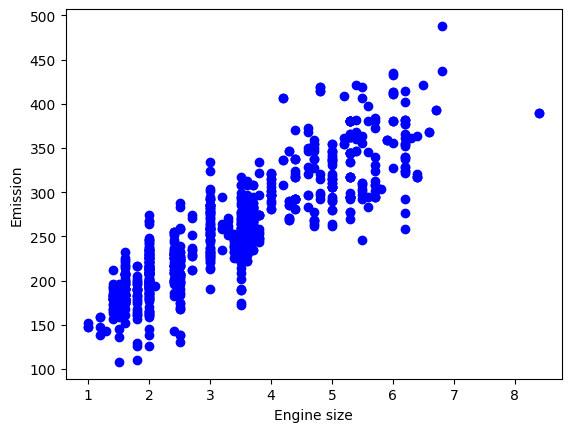

In [27]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS,  color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

In [28]:
train.ENGINESIZE.size

868

In [29]:
train.CO2EMISSIONS.size

868

In [30]:
from sklearn import linear_model
regr = linear_model.LinearRegression()
train_x = train[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB']]
train_y = train[['CO2EMISSIONS']]
regr.fit (train_x, train_y)

print ('Coefficients: ', regr.coef_)
print ('Intercept: ', regr.intercept_)

Coefficients:  [[10.40745985  8.11375973  9.39542878]]
Intercept:  [65.41284196]


**Explained variance regression score:**\
Let $\hat{y}$ be the estimated target output, y the corresponding (correct) target output, and Var be the Variance (the square of the standard deviation). Then the explained variance is estimated as follows:

$\texttt{explainedVariance}(y, \hat{y}) = 1 - \frac{Var{ y - \hat{y}}}{Var{y}}$\
The best possible score is 1.0, the lower values are worse.


In [31]:
test_x = test[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB']]
test_y = test[['CO2EMISSIONS']]
y_hat = regr.predict(test_x)

# Explained variance score: 1 is perfect prediction
print('Variance score: %.2f' % regr.score(test_x, test_y))

Variance score: 0.86


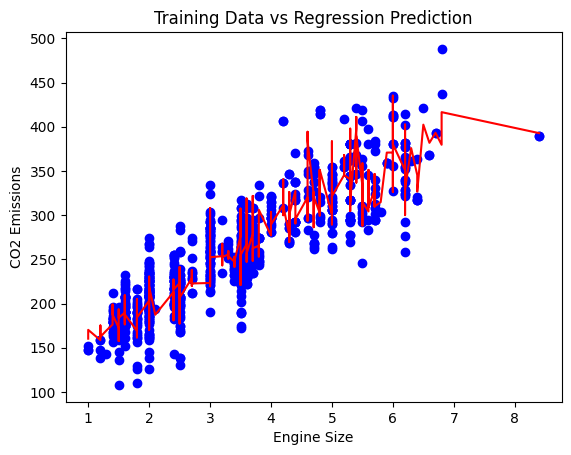

In [ ]:
plt.scatter(train['ENGINESIZE'], train['CO2EMISSIONS'], color='blue')

y_pred = regr.predict(train_x)

sorted_index = train['ENGINESIZE'].argsort()

plt.plot(
    train['ENGINESIZE'].iloc[sorted_index],
    y_pred[sorted_index],
    color='red'
)

plt.xlabel("Engine Size")
plt.ylabel("CO2 Emissions")
plt.title("Training Data vs Regression Prediction")

plt.show()


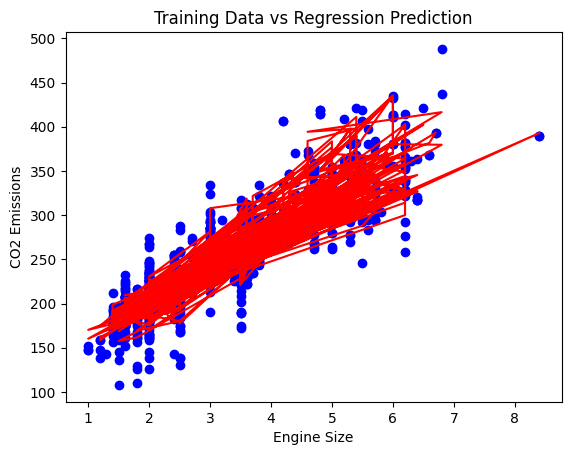

In [42]:
plt.scatter(train['ENGINESIZE'], train['CO2EMISSIONS'], color='blue')

y_pred = regr.predict(train_x)

plt.plot(
    train['ENGINESIZE'],
    y_pred,
    color='red'
)

plt.xlabel("Engine Size")
plt.ylabel("CO2 Emissions")
plt.title("Training Data vs Regression Prediction")

plt.show()

In [43]:
# for myself
x = np.array([2.4, 1.6, 3.0, 2.0])
np.argsort(x)

array([1, 3, 0, 2])